[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link] [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link] [![JupyterHub](https://img.shields.io/badge/Jupyter_Hub-orange?style=for-the-badge)][jupyter-link]

[download-link]: https://github.com/nmfs-opensci/nmfshackdays-2026/blob/main/topics/2026-04-17/erddap_tabledap.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2026/blob/main/topics/2026-04-17/erddap_tabledap.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2026/main/topics/2026-04-17/erddap_tabledap.ipynb

## Overview

ERDDAP provides two data access modes: griddap for multidimensional gridded datasets that can be sliced by dimensions (e.g., time, latitude, longitude), and tabledap for tabular datasets that are queried by filtering rows (e.g., observations or profiles).

The new erddapy release provides a `erdappy` engine which helps us open tabledap urls in a nicer way.

In [3]:
# make sure we have at least 3.1.1
# On JupyterHub run pip install --upgrade erddapy
# and restart kernel
import erddapy
erddapy.__version__

'3.1.1'

In [4]:
import xarray as xr
xr.backends.list_engines()

{'netcdf4': <NetCDF4BackendEntrypoint>
   Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html,
 'h5netcdf': <H5netcdfBackendEntrypoint>
   Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using h5netcdf in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.H5netcdfBackendEntrypoint.html,
 'scipy': <ScipyBackendEntrypoint>
   Open netCDF files (.nc, .cdf and .nc.gz) using scipy in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html,
 'erddapy': <ERDDAPyBackendEntrypoint>
   Load ERDDAP URLs in xarray.,
 'gmt': <GMTBackendEntrypoint>
   Open raster (.grd, .nc or .tif) files in Xarray via GMT.
   Learn more at https://pygmt.org/dev/api/generated/pygmt.GMTBackendEntrypoint.html,
 'h5coro': <H5CoroBackendEntrypoint>
   Support for reading HDF5 files in S3 from H5Cor

In [5]:
import xarray as xr
#from erddapy import ERDDAP

url = "https://gliders.ioos.us/erddap/tabledap/amelia-20180501T0000"
#url = "https://coastwatch.pfeg.noaa.gov/erddap/tabledap/erdCalCOFIeggcnt"
#xr.open_dataset(url, engine="erddapy")
xr.open_dataset(url)

<xarray.Dataset> Size: 643kB
Dimensions:                                    (s: 1397)
Dimensions without coordinates: s
Data variables: (12/73)
    s.trajectory                               (s) |S64 89kB ...
    s.wmo_id                                   (s) |S64 89kB ...
    s.profile_id                               (s) float64 11kB ...
    s.time                                     (s) datetime64[ns] 11kB ...
    s.latitude                                 (s) float64 11kB ...
    s.longitude                                (s) float64 11kB ...
    ...                                         ...
    s.time_uv                                  (s) datetime64[ns] 11kB ...
    s.time_uv_qc                               (s) float32 6kB ...
    s.u                                        (s) float64 11kB ...
    s.u_qc                                     (s) float32 6kB ...
    s.v                                        (s) float64 11kB ...
    s.v_qc                                     (s) float32 6kB ...
Attributes: (12/56)
    acknowledgment:                This deployment supported by Heising-Simon...
    cdm_data_type:                 TrajectoryProfile
    cdm_profile_variables:         time_uv,lat_uv,lon_uv,u,v,profile_id,time,...
    cdm_trajectory_variables:      trajectory,wmo_id
    contributor_name:              Donglai Gong, Jeanna Hudson, Lydia Bienlie...
    contributor_role:              Principal Investigator, Glider Pilot, Glid...
    ...                            ...
    subsetVariables:               wmo_id,trajectory,profile_id,time,latitude...
    summary:                       This is a test mission for the Northwest P...
    time_coverage_end:             2018-05-14T12:29:12Z
    time_coverage_start:           2018-05-01T14:58:48Z
    title:                         amelia-20180501T0000
    Westernmost_Easting:           -75.07957909499224

In [6]:
import xarray as xr
from erddapy import ERDDAP

url = "https://gliders.ioos.us/erddap/tabledap/amelia-20180501T0000"
# url = "https://coastwatch.pfeg.noaa.gov/erddap/tabledap/erdCalCOFIeggcnt"
xr.open_dataset(url, engine="erddapy")

<xarray.Dataset> Size: 643kB
Dimensions:                                    (s: 1397)
Dimensions without coordinates: s
Data variables: (12/73)
    s.trajectory                               (s) |S64 89kB ...
    s.wmo_id                                   (s) |S64 89kB ...
    s.profile_id                               (s) float64 11kB ...
    s.time                                     (s) datetime64[ns] 11kB ...
    s.latitude                                 (s) float64 11kB ...
    s.longitude                                (s) float64 11kB ...
    ...                                         ...
    s.time_uv                                  (s) datetime64[ns] 11kB ...
    s.time_uv_qc                               (s) float32 6kB ...
    s.u                                        (s) float64 11kB ...
    s.u_qc                                     (s) float32 6kB ...
    s.v                                        (s) float64 11kB ...
    s.v_qc                                     (s) float32 6kB ...
Attributes: (12/56)
    acknowledgment:                This deployment supported by Heising-Simon...
    cdm_data_type:                 TrajectoryProfile
    cdm_profile_variables:         time_uv,lat_uv,lon_uv,u,v,profile_id,time,...
    cdm_trajectory_variables:      trajectory,wmo_id
    contributor_name:              Donglai Gong, Jeanna Hudson, Lydia Bienlie...
    contributor_role:              Principal Investigator, Glider Pilot, Glid...
    ...                            ...
    subsetVariables:               wmo_id,trajectory,profile_id,time,latitude...
    summary:                       This is a test mission for the Northwest P...
    time_coverage_end:             2018-05-14T12:29:12Z
    time_coverage_start:           2018-05-01T14:58:48Z
    title:                         amelia-20180501T0000
    Westernmost_Easting:           -75.07957909499224

In [7]:
url = "https://coastwatch.pfeg.noaa.gov/erddap/tabledap/erdCalCOFIeggcnt"
xr.open_dataset(url, engine="erddapy")

<xarray.Dataset> Size: 48MB
Dimensions:                 (s: 93502)
Dimensions without coordinates: s
Data variables: (12/22)
    s.cruise                (s) |S64 6MB ...
    s.ship                  (s) |S64 6MB ...
    s.ship_code             (s) |S64 6MB ...
    s.order_occupied        (s) int32 374kB ...
    s.tow_type              (s) |S64 6MB ...
    s.tow_number            (s) int32 374kB ...
    ...                      ...
    s.common_name           (s) |S64 6MB ...
    s.itis_tsn              (s) int32 374kB ...
    s.calcofi_species_code  (s) int32 374kB ...
    s.egg_count             (s) int32 374kB ...
    s.eggs_10m2             (s) float32 374kB ...
    s.eggs_100m3            (s) float32 374kB ...
Attributes: (12/26)
    cdm_data_type:             Other
    Conventions:               COARDS, CF-1.6, ACDD-1.3, NCCSV-1.2
    defaultGraphQuery:         longitude,latitude,egg_count&cruise="202301"&....
    Easternmost_Easting:       -77.22833
    geospatial_lat_max:        53.27666
    geospatial_lat_min:        0.001666
    ...                        ...
    subsetVariables:           cruise, station, line, tow_type, tow_number,ne...
    summary:                   Fish egg counts and standardized counts for eg...
    time_coverage_end:         2023-01-25T18:45:00Z
    time_coverage_start:       1951-01-09T18:16:00Z
    title:                     CalCOFI NOAA Fish Egg Counts
    Westernmost_Easting:       -179.8217

In [7]:
url = "https://gliders.ioos.us/erddap/tabledap/amelia-20180501T0000.ncCFMA"
ds = xr.open_dataset(url, engine="erddapy")

<xarray.Dataset> Size: 101MB
Dimensions:                                  (trajectory: 1, profile: 1397,
                                              obs: 279)
Coordinates:
  * trajectory                               (trajectory) object 8B 'amelia-2...
    time                                     (trajectory, profile) datetime64[ns] 11kB ...
    latitude                                 (trajectory, profile) float64 11kB ...
    longitude                                (trajectory, profile) float64 11kB ...
    lat_uv                                   (trajectory, profile) float64 11kB ...
    lon_uv                                   (trajectory, profile) float64 11kB ...
    time_uv                                  (trajectory, profile) datetime64[ns] 11kB ...
    depth                                    (trajectory, profile, obs) float32 2MB ...
Dimensions without coordinates: profile, obs
Data variables: (12/65)
    wmo_id                                   (trajectory) object 8B ...
    profile_id                               (trajectory, profile) float64 11kB ...
    u                                        (trajectory, profile) float64 11kB ...
    v                                        (trajectory, profile) float64 11kB ...
    conductivity                             (trajectory, profile, obs) float32 2MB ...
    conductivity_qc                          (trajectory, profile, obs) float32 2MB ...
    ...                                       ...
    temperature                              (trajectory, profile, obs) float32 2MB ...
    temperature_qc                           (trajectory, profile, obs) float32 2MB ...
    time_qc                                  (trajectory, profile, obs) float32 2MB ...
    time_uv_qc                               (trajectory, profile, obs) float32 2MB ...
    u_qc                                     (trajectory, profile, obs) float32 2MB ...
    v_qc                                     (trajectory, profile, obs) float32 2MB ...
Attributes: (12/56)
    acknowledgment:                This deployment supported by Heising-Simon...
    cdm_data_type:                 TrajectoryProfile
    cdm_profile_variables:         time_uv,lat_uv,lon_uv,u,v,profile_id,time,...
    cdm_trajectory_variables:      trajectory,wmo_id
    contributor_name:              Donglai Gong, Jeanna Hudson, Lydia Bienlie...
    contributor_role:              Principal Investigator, Glider Pilot, Glid...
    ...                            ...
    subsetVariables:               wmo_id,trajectory,profile_id,time,latitude...
    summary:                       This is a test mission for the Northwest P...
    time_coverage_end:             2018-05-14T12:29:12Z
    time_coverage_start:           2018-05-01T14:58:48Z
    title:                         amelia-20180501T0000
    Westernmost_Easting:           -75.07957909499224

In [11]:
import xarray as xr

url = "https://gliders.ioos.us/erddap/tabledap/amelia-20180501T0000.ncCFMA"

ds = xr.open_dataset(url, engine="erddapy")
print(ds)

<xarray.Dataset> Size: 101MB
Dimensions:                                  (trajectory: 1, profile: 1397,
                                              obs: 279)
Coordinates:
  * trajectory                               (trajectory) object 8B 'amelia-2...
    time                                     (trajectory, profile) datetime64[ns] 11kB ...
    latitude                                 (trajectory, profile) float64 11kB ...
    longitude                                (trajectory, profile) float64 11kB ...
    lat_uv                                   (trajectory, profile) float64 11kB ...
    lon_uv                                   (trajectory, profile) float64 11kB ...
    time_uv                                  (trajectory, profile) datetime64[ns] 11kB ...
    depth                                    (trajectory, profile, obs) float32 2MB ...
Dimensions without coordinates: profile, obs
Data variables: (12/65)
    wmo_id                                   (trajectory) object 8B ..

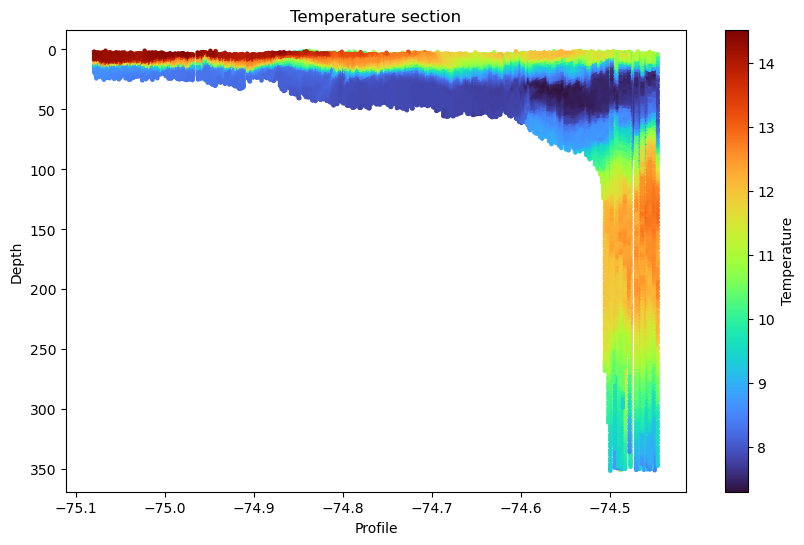

In [35]:
da = ds.temperature.isel(trajectory=0)

plt.figure(figsize=(10, 6))

plt.scatter(
    ds.longitude.broadcast_like(da),
    ds.depth.isel(trajectory=0),
    c=da,
    s=5,
    cmap="turbo"
)

plt.gca().invert_yaxis()

plt.xlabel("Profile")
plt.ylabel("Depth")
plt.title("Temperature section")
plt.colorbar(label="Temperature")

plt.show()

In [23]:
da

<xarray.DataArray 'temperature' (profile: 1397, obs: 258)> Size: 1MB
array([[8.0939, 8.108 , 8.321 , ...,    nan,    nan,    nan],
       [8.4498, 9.2764, 9.4987, ...,    nan,    nan,    nan],
       [9.6915, 9.7053, 9.7546, ...,    nan,    nan,    nan],
       ...,
       [8.6176, 8.6306, 8.6348, ...,    nan,    nan,    nan],
       [8.6349, 8.6356, 8.6499, ...,    nan,    nan,    nan],
       [8.639 , 8.6735, 9.4113, ...,    nan,    nan,    nan]],
      shape=(1397, 258), dtype=float32)
Coordinates:
    trajectory  <U20 80B 'amelia-20180501T0000'
    time        (profile) datetime64[ns] 11kB ...
    latitude    (profile) float64 11kB ...
    longitude   (profile) float64 11kB ...
    lat_uv      (profile) float64 11kB ...
    lon_uv      (profile) float64 11kB ...
    time_uv     (profile) datetime64[ns] 11kB ...
    depth       (profile, obs) float32 1MB ...
Dimensions without coordinates: profile, obs
Attributes: (12/14)
    _ChunkSizes:          10
    actual_range:         [ 7.2979 14.5184]
    ancillary_variables:  qartod_temperature_climatological_flag qartod_tempe...
    colorBarMaximum:      32.0
    colorBarMinimum:      0.0
    instrument:           instrument_ctd
    ...                   ...
    observation_type:     measured
    platform:             platform
    standard_name:        sea_water_temperature
    units:                Celsius
    valid_max:            40.0
    valid_min:            -5.0

In [21]:
ds.temperature.isel(trajectory=0)

<xarray.DataArray 'temperature' (profile: 1397, obs: 279)> Size: 2MB
array([[8.0939, 8.108 , 8.321 , ...,    nan,    nan,    nan],
       [8.4498, 9.2764, 9.4987, ...,    nan,    nan,    nan],
       [9.6915, 9.7053, 9.7546, ...,    nan,    nan,    nan],
       ...,
       [8.6176, 8.6306, 8.6348, ...,    nan,    nan,    nan],
       [8.6349, 8.6356, 8.6499, ...,    nan,    nan,    nan],
       [8.639 , 8.6735, 9.4113, ...,    nan,    nan,    nan]],
      shape=(1397, 279), dtype=float32)
Coordinates:
    trajectory  <U20 80B 'amelia-20180501T0000'
    time        (profile) datetime64[ns] 11kB ...
    latitude    (profile) float64 11kB ...
    longitude   (profile) float64 11kB ...
    lat_uv      (profile) float64 11kB ...
    lon_uv      (profile) float64 11kB ...
    time_uv     (profile) datetime64[ns] 11kB ...
    depth       (profile, obs) float32 2MB ...
Dimensions without coordinates: profile, obs
Attributes: (12/14)
    _ChunkSizes:          10
    actual_range:         [ 7.2979 14.5184]
    ancillary_variables:  qartod_temperature_climatological_flag qartod_tempe...
    colorBarMaximum:      32.0
    colorBarMinimum:      0.0
    instrument:           instrument_ctd
    ...                   ...
    observation_type:     measured
    platform:             platform
    standard_name:        sea_water_temperature
    units:                Celsius
    valid_max:            40.0
    valid_min:            -5.0

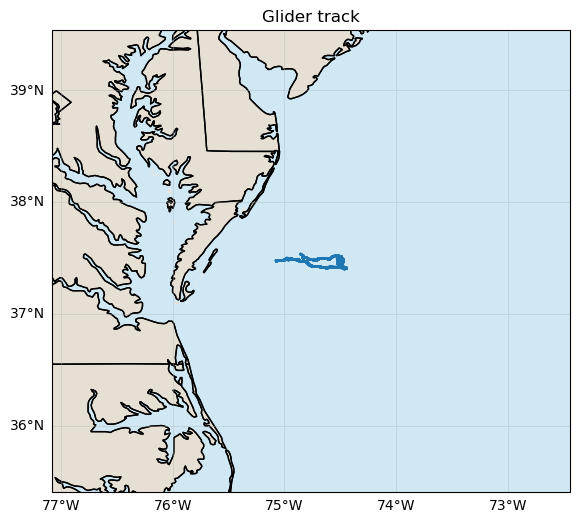

In [34]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lon = ds.longitude.isel(trajectory=0)
lat = ds.latitude.isel(trajectory=0)

fig = plt.figure(figsize=(8, 6))

ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent around the track
ax.set_extent([
    float(lon.min()) - 2,
    float(lon.max()) + 2,
    float(lat.min()) - 2,
    float(lat.max()) + 2,
])

# Add coastline and land
ax.add_feature(cfeature.LAND, facecolor="#e6e0d4")
ax.add_feature(cfeature.OCEAN, facecolor="#cfe8f3")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES)

# Optional gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Plot track
ax.plot(
    lon,
    lat,
    marker=".",
    markersize=2,
    transform=ccrs.PlateCarree(),
)

plt.title("Glider track")
plt.show()

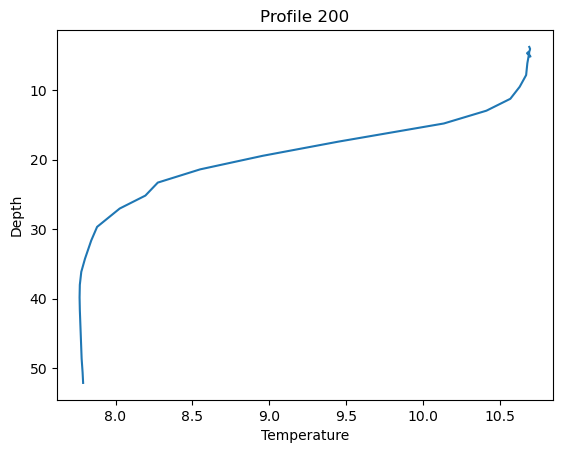

In [15]:
p = 200

plt.plot(
    ds.temperature.isel(trajectory=0, profile=p),
    ds.depth.isel(trajectory=0, profile=p)
)

plt.gca().invert_yaxis()

plt.xlabel("Temperature")
plt.ylabel("Depth")
plt.title(f"Profile {p}")
plt.show()